# EL GHALI MOHAMED

## Partie 1 KNN pour Classification

#### L'Algorithme des K-Plus Proches Voisins (KNN)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Creation du dataset

In [3]:
# 1. Create the dataset
data = {
    'Weight (g)': [
        # 20 samples of Apples
        150, 155, 142, 158, 160, 153, 148, 170, 165, 159,
        145, 151, 157, 162, 144, 156, 168, 161, 149, 152,
        # 20 samples of Lemons
        120, 115, 122, 110, 118, 125, 112, 130, 128, 114,
        121, 117, 123, 111, 119, 126, 113, 131, 129, 116,
        # 20 samples of Oranges
        200, 210, 195, 205, 215, 202, 198, 220, 212, 208,
        201, 211, 196, 206, 216, 203, 199, 221, 213, 209
    ],
    'Sweetness (1-10)': [
        # Apples
        7.2, 7.5, 6.8, 8.0, 7.1, 7.3, 6.9, 8.2, 7.8, 7.4,
        6.7, 7.0, 7.6, 8.1, 6.6, 7.7, 8.3, 7.9, 7.1, 7.2,
        # Lemons
        3.1, 2.5, 3.3, 2.1, 2.8, 3.5, 2.2, 4.0, 3.8, 2.4,
        3.2, 2.7, 3.4, 2.0, 2.9, 3.6, 2.3, 4.1, 3.9, 2.6,
        # Oranges
        6.2, 6.5, 5.8, 7.0, 6.1, 6.3, 5.9, 7.2, 6.8, 6.4,
        6.1, 6.6, 5.7, 7.1, 6.0, 6.3, 5.9, 7.3, 6.7, 6.5
    ],
    'Fruit': [
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon',
        'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon', 'Lemon',
        'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange',
        'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange'
    ]
}

df = pd.DataFrame(data)

# x contains Weight and sweetness
X = df[['Weight (g)', 'Sweetness (1-10)']]
# y contains only the Fruit name
y = df['Fruit']

## La fonction de distance (Norme $L_2$)

On commence par définir la distance Euclidienne pour deux points $p$ et $q$.


In [4]:
def distance_euclidienne(p, q):
    distance = 0
    # On fait la somme des carrés des différences pour chaque caractéristique
    for i in range(len(p)):
        distance += (p[i] - q[i]) ** 2
    return distance**0.5

## Fonction pour choisir le meilleur K (Validation Croisée)

In [5]:
def evaluer_k(X, y, k_max=10):
    # On sépare manuellement (ex: 80% train, 20% test)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    meilleur_k = 1
    meilleure_precision = 0

    for k in range(1, k_max + 1):
        correct = 0
        # On teste le modèle sur chaque point du jeu de test
        for i in range(len(X_test)):
            prediction = knn_from_scratch(X_train, y_train, X_test[i], k)
            if prediction == y_test[i]:
                correct += 1

        precision = correct / len(X_test)
        print(f"K = {k} | Précision : {precision:.2%}")

        if precision >= meilleure_precision:
            meilleure_precision = precision
            meilleur_k = k

    return meilleur_k

## Fonction KNN pr classification

In [6]:
def knn_from_scratch(X_train, y_train, x_nouveau, k):
    distances = []

    #  1 : Calculer la distance entre le nouveau point et TOUS les points d'entraînement
    for i in range(len(X_train)):
        d = distance_euclidienne(X_train[i], x_nouveau)
        distances.append((d, y_train[i]))

    #  2 : Trier par distance (ordre croissant)
    # On utilise sorted() qui va trier sur le premier élément du tuple (la distance)
    distances.sort(key=lambda x: x[0])

    # 3 : Garder les K plus proches
    voisins = distances[:k]

    #  4 : Vote de la majorité (Règle de décision)
    votes = {}
    for v in voisins:
        label = v[1]
        votes[label] = votes.get(label, 0) + 1

    # Trouver la classe qui a le plus de votes
    classe_finale = max(votes, key=votes.get)

    return classe_finale

#### Representaion Graphique

K = 1 | Précision : 100.00%
K = 2 | Précision : 100.00%
K = 3 | Précision : 100.00%
Le fruit a été classé comme : Apple


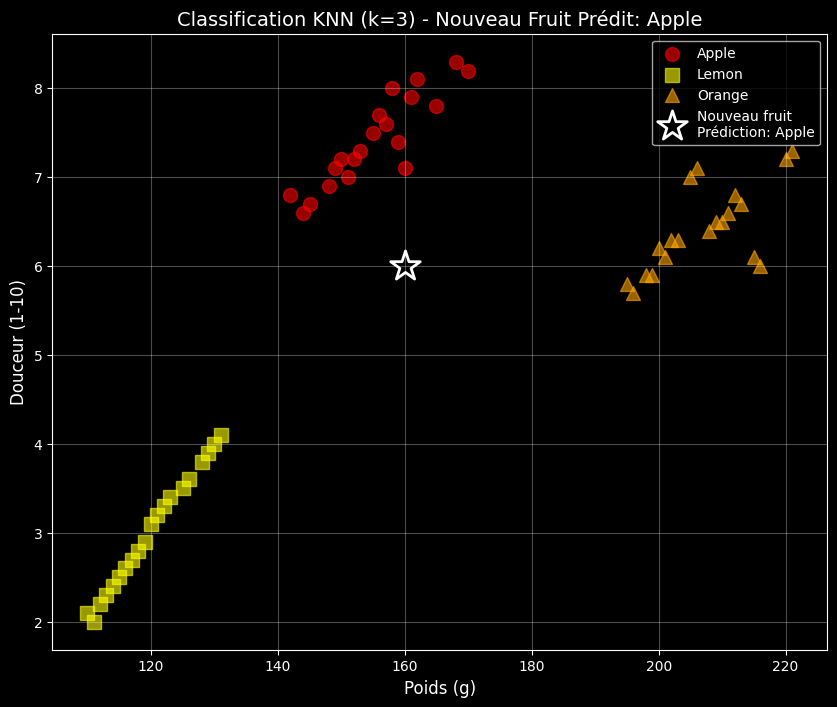

In [7]:
# On cherche la meilleure valeur pour k (le nombre de voisins à consulter)
k = evaluer_k(X.values, y.values, k_max=3)

# On définit notre nouveau fruit mystère (Poids: 160g, Douceur: 7)
new_fruit = np.array([160, 6])

# Utilisation  du notre fonction "maison" pour prédire la catégorie
prediction = knn_from_scratch(X.values, y.values, new_fruit, k)

# --- PRÉPARATION DU GRAPHIQUE ---

# On définit la taille de la figure
plt.figure(figsize=(10, 8))

# Creation  d'un dictionnaire pour associer chaque fruit à une couleur et une forme
couleurs = {'Apple': 'red', 'Lemon': 'yellow', 'Orange': 'orange'}
marqueurs = {'Apple': 'o', 'Lemon': 's', 'Orange': '^'} #o: circle, s: rectangle,^: triangle

# On dessine les points des fruits déjà connus du notre base dataset
for fruit in df['Fruit'].unique():
    mask = df['Fruit'] == fruit
    plt.scatter(df.loc[mask, 'Weight (g)'],
               df.loc[mask, 'Sweetness (1-10)'],
               c=couleurs[fruit], label=fruit,
               marker=marqueurs[fruit], s=100, alpha=0.6)

# On dessine le nouveau fruit sous forme d'une grosse étoile noire
plt.scatter([160], [6], c='black', marker='*',
               s=500, label=f'Nouveau fruit\nPrédiction: {prediction}',
               edgecolors='white', linewidth=2)

# Affichage du résultat dans la console
print(f"Le fruit a été classé comme : {prediction}")

# 6. Habillage du graphique (titres, légendes, grille)
plt.xlabel('Poids (g)', fontsize=12)
plt.ylabel('Douceur (1-10)', fontsize=12)
plt.title(f'Classification KNN (k={k}) - Nouveau Fruit Prédit: {prediction}', fontsize=14)
plt.legend(loc='best', fontsize=10) # Affiche la boîte de légende
plt.grid(True, alpha=0.3)           # Ajoute une grille légère en fond
plt.show()                          # Affiche le graphique final

## Partie : KNN pour la regression

#### Le Dataset
Ce dataset contient 25 appartements. Les caractéristiques ($X$) sont la surface et l'âge, et la cible ($y$) est le prix en million du Dirham (MAD).

In [8]:
data_reg = {
    'Surface_m2': [
        30, 45, 50, 60, 35, 80, 100, 120, 40, 55,
        150, 25, 90, 70, 110, 65, 42, 130, 85, 38,
        52, 75, 140, 28, 95
    ],
    'Age_ans': [
        5, 15, 10, 2, 25, 8, 1, 20, 30, 12,
        5, 40, 15, 3, 10, 25, 18, 7, 12, 5,
        2, 20, 15, 35, 1
    ],
    'Prix_M_dirham': [
        1.2, 1.5, 1.7, 2.1, 0.95, 2.8, 3.5, 3.2, 1.05, 1.65,
        5.0, 0.8, 2.4, 2.3, 3.1, 1.8, 1.35, 4.1, 2.55, 1.450,
        1.95, 2.05, 4.3, 0.85, 3.4
    ]
}

# Pour séparer les features (X) et la cible (y) :
X = [list(item) for item in zip(data_reg['Surface_m2'], data_reg['Age_ans'])]
y = data_reg['Prix_M_dirham']

#### Choisissant K optimal (Validation Croisée)

In [9]:
def evaluer_k_regression(X, y, k_max=10):
    # Séparation 80% train / 20% test
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    meilleur_k = 1
    plus_petite_erreur = float('inf') # On cherche le minimum, donc on part de l'infini

    for k in range(1, k_max + 1):
        somme_erreurs_au_carre = 0

        for i in range(len(X_test)):
            # Appeler la fonction de régression (qui fait la moyenne)
            prediction = knn_regression_from_scratch(X_train, y_train, X_test[i], k)

            # Calcul de l'écart au carré
            erreur = (y_test[i] - prediction) ** 2
            somme_erreurs_au_carre += erreur

        # Calcul de la moyenne des erreurs pour ce k
        mse = somme_erreurs_au_carre / len(X_test)
        print(f"K = {k} | Erreur Moyenne (MSE) : {mse:.4f}")

        # On garde le K qui a l'erreur la plus faible
        if mse < plus_petite_erreur:
            plus_petite_erreur = mse
            meilleur_k = k

    return meilleur_k

#### KNN from scratch

In [10]:
def knn_regression_from_scratch(X_train, y_train, x_nouveau, k):
    distances = []

    # 1. Calculer les distances
    for i in range(len(X_train)):
        d = distance_euclidienne(X_train[i], x_nouveau)
        distances.append((d, y_train[i]))

    # 2. Trier par distance
    distances.sort(key=lambda x: x[0])

    # 3. Prendre les k plus proches
    voisins = distances[:k]

    # 4. LOGIQUE RÉGRESSION : On fait la MOYENNE
    moyenne = 0
    for v in voisins:
        moyenne += v[1] # v[1] est le prix du voisin

    prediction = moyenne / k
    return prediction


#### Representaion Graphique

K = 1 | Erreur Moyenne (MSE) : 1.8225
K = 2 | Erreur Moyenne (MSE) : 1.9600
K = 3 | Erreur Moyenne (MSE) : 0.4011
K = 4 | Erreur Moyenne (MSE) : 1.2377
K = 5 | Erreur Moyenne (MSE) : 2.4649
K = 6 | Erreur Moyenne (MSE) : 3.5156
K = 7 | Erreur Moyenne (MSE) : 4.3801
K = 8 | Erreur Moyenne (MSE) : 5.0907
K = 9 | Erreur Moyenne (MSE) : 5.6803
K = 10 | Erreur Moyenne (MSE) : 6.1752


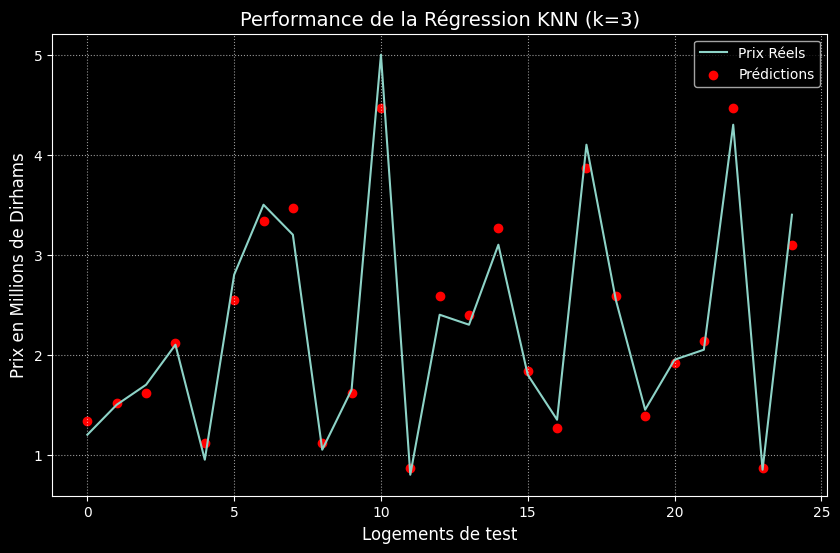

In [11]:
# --- PRÉPARATION DES DONNÉES DE TEST ---
split = int(len(X) * 0.8)
X_test = X[split:]
y_reels = y[split:]
#evaluation de k optimal
k_opti = evaluer_k_regression(X_test, y_reels)

# Calcul des prédictions pour chaque point
y_predits = [knn_regression_from_scratch(X[:split], y[:split], x, k_opti) for x in X_test]

# --- Graphe ---
plt.figure(figsize=(10, 6))

# Pour afficher tout le dataset (sans distinction train/test)
y_total_predit = [knn_regression_from_scratch(X, y, x, k_opti) for x in X]
plt.plot(y, label='Prix Réels')
plt.scatter(range(len(y_total_predit)), y_total_predit, label='Prédictions', color='red')

plt.title(f'Performance de la Régression KNN (k={k_opti})', fontsize=14)
plt.ylabel('Prix en Millions de Dirhams', fontsize=12)
plt.xlabel('Logements de test', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()